In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [ ]:
#This file is being read from the archived dataset in our zip folder. Please use this if running this notebook.
df = pd.read_csv('archived datasets/diamond_processed.csv')
df

,Unnamed: 0,carat,cut,color,clarity,average us salary,number of diamonds mined (millions),depth,table,price,x,y,z
0,1.0,0.23,IDEAL,E,SI2,31282,5.01,61.5,55.0,326.0,3.95,3.98,2.43
1,2.0,0.21,PREMIUM,E,SI1,40049,1.69,59.8,61.0,326.0,3.89,3.84,2.31
2,3.0,0.23,GOOD,E,VS1,33517,3.85,56.9,65.0,327.0,4.05,4.07,2.31
3,4.0,0.29,PREMIUM,I,VS2,38495,3.49,62.4,58.0,334.0,4.20,4.23,2.63
4,5.0,0.31,GOOD,J,SI2,34178,4.70,63.3,58.0,335.0,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,53936.0,0.72,IDEAL,D,SI1,43892,3.54,60.8,57.0,2757.0,5.75,5.76,3.50
53936,53937.0,0.72,GOOD,D,SI1,35532,3.51,63.1,55.0,2757.0,5.69,5.75,3.61
53937,53938.0,0.70,VERY GOOD,D,SI1,32133,3.27,62.8,60.0,2757.0,5.66,5.68,3.56
53938,53939.0,0.86,PREMIUM,H,SI2,44248,4.03,61.0,58.0,2757.0,6.15,6.12,3.74


In [ ]:
df.drop('Unnamed: 0', axis = 1,inplace=True)

In [ ]:
#Reusing my code from Assignment 0

#Country
cut  = pd.Categorical(df['cut'])
df['cut_categorical'] = cut.codes
df.drop('cut', axis=1, inplace=True)

color = pd.Categorical(df['color'])
df['color_categorical'] = color.codes
df.drop('color', axis=1, inplace=True)

clarity = pd.Categorical(df['clarity'])
df['clarity_categorical'] = clarity.codes
df.drop('clarity', axis=1, inplace=True)

df

,carat,average us salary,number of diamonds mined (millions),depth,table,price,x,y,z,cut_categorical,color_categorical,clarity_categorical
0,0.23,31282,5.01,61.5,55.0,326.0,3.95,3.98,2.43,3,1,5
1,0.21,40049,1.69,59.8,61.0,326.0,3.89,3.84,2.31,5,1,4
2,0.23,33517,3.85,56.9,65.0,327.0,4.05,4.07,2.31,2,1,7
3,0.29,38495,3.49,62.4,58.0,334.0,4.20,4.23,2.63,5,6,8
4,0.31,34178,4.70,63.3,58.0,335.0,4.34,4.35,2.75,2,7,5
...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.72,43892,3.54,60.8,57.0,2757.0,5.75,5.76,3.50,3,0,4
53936,0.72,35532,3.51,63.1,55.0,2757.0,5.69,5.75,3.61,2,0,4
53937,0.70,32133,3.27,62.8,60.0,2757.0,5.66,5.68,3.56,7,0,4
53938,0.86,44248,4.03,61.0,58.0,2757.0,6.15,6.12,3.74,5,5,5


In [ ]:
#Removing uncorrelated features with atrget variables
correlation_matrix = pd.DataFrame.corr(df)

In [ ]:
target_corr = correlation_matrix['price']
target_corr

,price
carat,0.687005
average us salary,0.000948
number of diamonds mined (millions),-0.004251
depth,0.004341
table,0.120690
price,1.000000
x,0.740895
y,0.725451
z,0.724402
cut_categorical,0.024921


In [ ]:
correlation_threshold = 0.1
features_dropped = target_corr[target_corr.abs() < correlation_threshold].index.tolist()
df.drop(columns=features_dropped, inplace = True, axis = 1)
df

,carat,table,price,x,y,z,color_categorical
0,0.23,55.0,326.0,3.95,3.98,2.43,1
1,0.21,61.0,326.0,3.89,3.84,2.31,1
2,0.23,65.0,327.0,4.05,4.07,2.31,1
3,0.29,58.0,334.0,4.20,4.23,2.63,6
4,0.31,58.0,335.0,4.34,4.35,2.75,7
...,...,...,...,...,...,...,...
53935,0.72,57.0,2757.0,5.75,5.76,3.50,0
53936,0.72,55.0,2757.0,5.69,5.75,3.61,0
53937,0.70,60.0,2757.0,5.66,5.68,3.56,0
53938,0.86,58.0,2757.0,6.15,6.12,3.74,5


In [ ]:
X = df.drop('price', axis = 1)
Y = df['price']

#Checking both the shapes
print(X.shape)
print(Y.shape)

(53940, 6)
(53940,)


In [ ]:
#Generating permutation to randomly shuffle
indices = np.random.permutation(len(X))
train_size = int(0.8 * len(X))
print(indices)

[17708  2026 35950 ... 35837 14949  1849]


In [ ]:
X_train = X.iloc[indices[:train_size]]
Y_train = Y.iloc[indices[:train_size]]
X_test = X.iloc[indices[train_size:]]
Y_test = Y.iloc[indices[train_size:]]

print("Shape of X_train is", X_train.shape)
print("Shape of Y_train is", Y_train.shape)
print("Shape of X_test is", X_test.shape)
print("Shape of Y_test is", Y_test.shape)

Shape of X_train is (43152, 6)
Shape of Y_train is (43152,)
Shape of X_test is (10788, 6)
Shape of Y_test is (10788,)


In [ ]:
df.columns

Index(['carat', 'table', 'price', 'x', 'y', 'z', 'color_categorical'], dtype='object')

In [ ]:
#Reusing my code from Assignment 0
columns = ['carat', 'x', 'y', 'z', 'table']
datasets = [X_train, X_test]
for dataset in datasets:
  for column in columns:
    max = dataset[column].max()
    min = dataset[column].min()
    dataset[column] = (dataset[column] - min) / (max - min)

<ipython-input-14-fcacccf1d4d5>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset[column] = (dataset[column] - min) / (max - min)


In [ ]:
max = Y_train.max()
min = Y_train.min()
Y_train = (Y_train - min) / (max - min)

max = Y_test.max()
min = Y_test.min()
Y_test = (Y_test - min) / (max - min)

In [ ]:
def elastic_net_loss(y_true, X, lambda1, lambda2, w):
  y_pred = np.dot(X, w)
  N = len(y_true)
  error = y_true - y_pred
  loss = (1 / (2 * N)) * np.sum(error ** 2) + (lambda1/2)*np.sum(w**2) + (lambda2)*np.sum(np.abs(w))
  return loss

In [ ]:
'''def gradient_descent(X, y_true, w, lambda1, lambda2, iterations):
    N = len(y_true)
    for i in range(iterations):
        Y_pred = X.dot(w)
        error = y_true - y_pred
        gradient = (1 / N) * (X.T.dot(error)) + lambda1 * w + lambda2 * np.sign(w)
        #w -= lr * gradient
    return gradient'''

'def gradient_descent(X, y_true, w, lambda1, lambda2, iterations):\n    N = len(y_true)\n    for i in range(iterations):\n        Y_pred = X.dot(w)\n        error = y_true - y_pred\n        gradient = (1 / N) * (X.T.dot(error)) + lambda1 * w + lambda2 * np.sign(w)\n        #w -= lr * gradient\n    return gradient'

In [ ]:
def random_initialization(dim):
    w = np.random.uniform(0, 1, size=dim)
    return w

def zero_initialization(dim):
    return np.zeros(dim)

def xavier_initialization(input_dim):
    limit = np.sqrt(6 / (input_dim))
    return np.random.uniform(-limit, limit, size=(input_dim,))

In [ ]:
def train_model(X, y_true, alpha, lambda1, lambda2, num_iterations, init_method):

    if init_method == 'random':
      w = random_initialization(X.shape[1])
    elif init_method == 'zero':
      w= zero_initialization(X.shape[1])
    elif init_method == 'xavier':
      w = xavier_initialization(X.shape[1])

    N = len(y_true)
    loss_history = []

    for i in range(num_iterations):
        y_pred = np.dot(X, w)
        error = y_true - y_pred
        loss = elastic_net_loss(y_true, X, lambda1, lambda2, w)
        loss_history.append(loss)

        gradient = -(1 / N) * (X.T.dot(error)) + lambda1 * w + lambda2 * np.sign(w)
        #if i % 1000 == 0:
        #  print(f'Iteration {i}, Weights: {w}, Gradient Norm: {np.linalg.norm(gradient)}')
        w = w - alpha * gradient
        #b -= alpha * np.mean(error)

        if np.all(gradient > -0.01) and np.all(gradient < 0.01):
          print(f'Stopping criteria met at iteration {i}')
          break

    return w, loss_history

In [ ]:
weight_random, loss_history_random = train_model(X_train, Y_train, alpha=0.003, lambda1=0.01, lambda2=0.01, num_iterations=6000, init_method='random')
weight_zero, loss_history_zero = train_model(X_train, Y_train, alpha=0.001, lambda1=0.01, lambda2=0.01, num_iterations=6000, init_method='zero')
weight_xavier, loss_history_xavier = train_model(X_train, Y_train, alpha=0.001, lambda1=0.01, lambda2=0.01, num_iterations=10000, init_method='xavier')

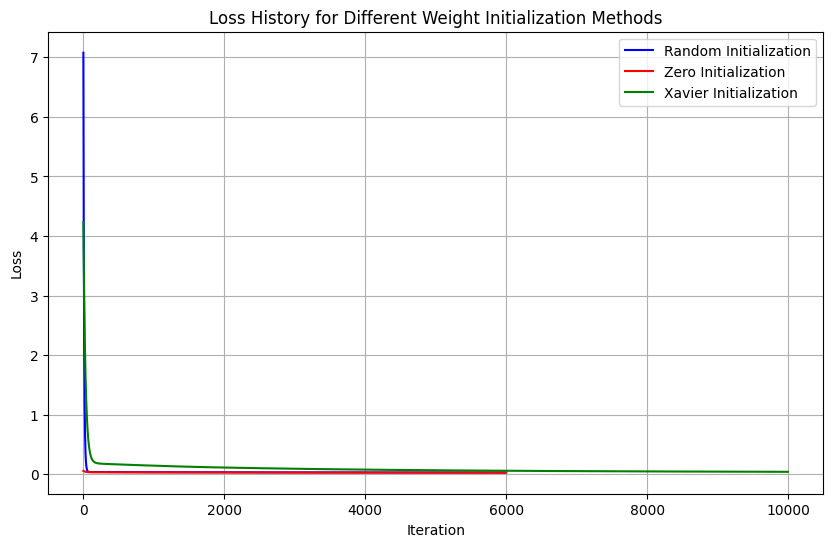

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(loss_history_random, label='Random Initialization', color='blue')
plt.plot(loss_history_zero, label='Zero Initialization', color='red')
plt.plot(loss_history_xavier, label='Xavier Initialization', color='green')

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss History for Different Weight Initialization Methods')
plt.legend()
plt.grid()
plt.show()

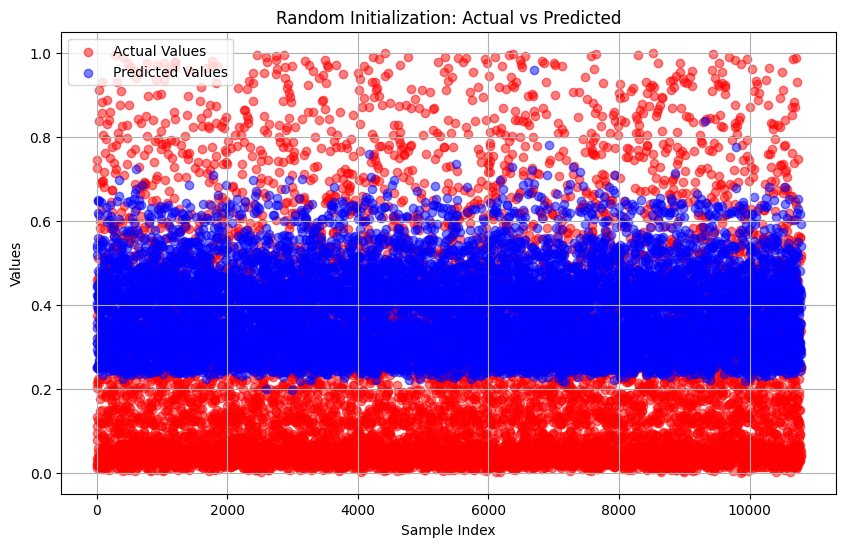

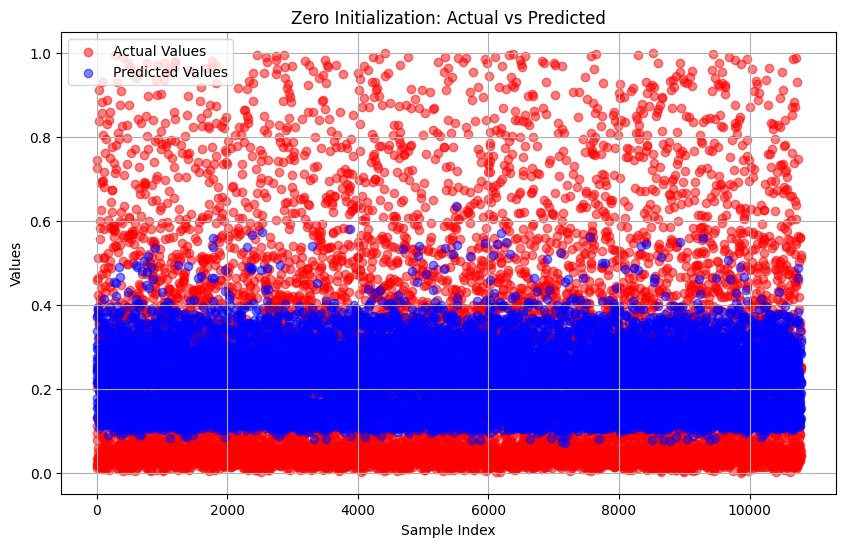

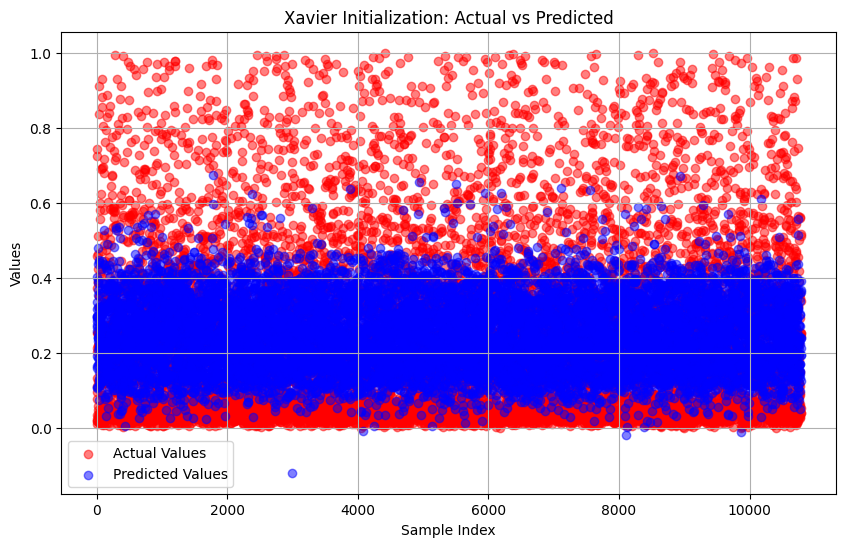

In [ ]:
def plot_actual_vs_predicted(y_true, y_pred, title):
    plt.figure(figsize=(10, 6))

    # Scatter plot for actual values
    plt.scatter(range(len(y_true)), y_true, color='red', alpha=0.5, label='Actual Values')

    # Scatter plot for predicted values
    plt.scatter(range(len(y_pred)), y_pred, color='blue', alpha=0.5, label='Predicted Values')

    plt.xlabel('Sample Index')
    plt.ylabel('Values')
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

pred_test_random = np.dot(X_test, weight_random)
pred_test_zero = np.dot(X_test, weight_zero)
pred_test_xavier = X_test.dot(weight_xavier)

# Plotting for each weight initialization method
plot_actual_vs_predicted(Y_test, pred_test_random, 'Random Initialization: Actual vs Predicted')
plot_actual_vs_predicted(Y_test, pred_test_zero, 'Zero Initialization: Actual vs Predicted')
plot_actual_vs_predicted(Y_test, pred_test_xavier, 'Xavier Initialization: Actual vs Predicted')

In [ ]:
loss_random = elastic_net_loss(Y_test, X_test, 0.01, 0.01, weight_random)
loss_zero = elastic_net_loss(Y_test, X_test, 0.01, 0.01, weight_zero)
loss_xavier = elastic_net_loss(Y_test, X_test, 0.01, 0.01, weight_xavier)

print("Loss random is", loss_random)
print("Loss zero is", loss_zero)
print("Loss xavier is", loss_xavier)

Loss random is 0.03664979570005809
Loss zero is 0.025835469877711927
Loss xavier is 0.03959539712999691


In [ ]:
import pickle
best_model = weight_zero
with open('best_model_part4.pkl', 'wb') as f:
  pickle.dump(best_model, f)

print("Weights saved")

Weights saved
